In [1]:
%pip install torchmetrics pycocotools

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import torch
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
import json
from PIL import Image
from torch.utils.data import Dataset, Subset, DataLoader
from collections import defaultdict
from sklearn.model_selection import train_test_split
from torchvision import transforms as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import time
import torch.backends.cudnn as cudnn
cudnn.benchmark = True
import albumentations as A
import cv2
from albumentations.pytorch import ToTensorV2
from torch.utils.data import WeightedRandomSampler
import numpy as np



DataSet 클래스

In [3]:
shape_configs = {
    '원형': {'folder': 'Model_Circle'},
    '장방형': {'folder': 'Model_Oblong'},
    '타원형': {'folder': 'Model_Oval'}
}
def get_label_mapping(ann_dir):
    unique_ids = set()
    for f in os.listdir(ann_dir):
        if f.endswith('.json'):
            with open(os.path.join(ann_dir, f), 'r', encoding='utf-8') as j:
                data = json.load(j)
                for ann in data.get('annotations', []):
                    unique_ids.add(ann['category_id'])
    
    sorted_ids = sorted(list(unique_ids))
    mapping = {old_id: i + 1 for i, old_id in enumerate(sorted_ids)}
    return mapping, sorted_ids

In [4]:
class PillDataset(Dataset):
    def __init__(self, img_dir, json_dir, label_mapping, transforms=None):
        self.img_dir = img_dir
        self.json_dir = json_dir
        self.label_mapping = label_mapping
        self.transforms = transforms
        self.img_files = [f for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg'))]

    def __getitem__(self, idx):
        img_name = self.img_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        json_name = os.path.splitext(img_name)[0] + ".json"
        json_path = os.path.join(self.json_dir, json_name)

        img = Image.open(img_path).convert("RGB")
        img = np.array(img)

        boxes, labels = [], []
        if os.path.exists(json_path):
            with open(json_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
            for ann in data.get("annotations", []):
                x, y, w, h = ann["bbox"]
                # [xmin, ymin, xmax, ymax]
                boxes.append([x, y, x + w, y + h])
                # 재매핑된 라벨 적용
                labels.append(self.label_mapping[ann["category_id"]])

        if self.transforms:
            transformed = self.transforms(image=img, bboxes=boxes, class_labels=labels)
            img = transformed["image"]
            new_boxes = np.array(transformed["bboxes"])
            new_labels = np.array(transformed["class_labels"])
        else:
            img = torch.as_tensor(img).permute(2, 0, 1).float() / 255.0
            new_boxes, new_labels = np.array(boxes), np.array(labels)

        target = {
            "boxes": torch.as_tensor(new_boxes, dtype=torch.float32) if len(new_boxes) > 0 else torch.zeros((0, 4)),
            "labels": torch.as_tensor(new_labels, dtype=torch.int64) if len(new_labels) > 0 else torch.zeros((0,), dtype=torch.int64),
            "image_id": torch.tensor([idx])
        }
        return img, target

    def __len__(self):
        return len(self.img_files)

In [5]:
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    total_loss = 0
    start_time = time.time()

    for i, batch in enumerate(data_loader):
        images, targets = batch
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += losses.item()
        # 10번의 반복마다 현재 상황 출력
        if i % 50 == 0:
            print(f"Epoch [{epoch}] Iter [{i}/{len(data_loader)}] "
                  f"Loss: {losses.item():.4f} "
                  f"(RPN_Obj: {loss_dict['loss_objectness']:.3f}, "
                  f"RPN_Reg: {loss_dict['loss_rpn_box_reg']:.3f}, "
                  f"Box: {loss_dict['loss_box_reg']:.3f})")
    avg_loss = total_loss / len(data_loader)
    elapsed = time.time() - start_time
    print(f"==> Epoch {epoch} 평균 Loss: {avg_loss:.4f} | 소요 시간: {elapsed:.1f}s")
    return avg_loss

In [6]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm import tqdm

def evaluate(model, data_loader, device):
    model.eval()
    
    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc="Evaluating"):
            images = list(img.to(device) for img in images)
            outputs = model(images) # 예측 결과 [{boxes, scores, labels}, ...]
            
            res_targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            filtered_outputs = []

            for o in outputs:
                boxes = o['boxes']
                scores = o['scores']
                labels = o['labels']

                valid_boxes = []
                valid_scores = []
                valid_labels = []

                for box, score, label in zip(boxes, scores, labels):
                    x1, y1, x2, y2 = box

                    if x2 <= x1 or y2 <= y1:
                        continue
                    
                    if score < 0.05:
                        continue
                    valid_boxes.append(box)
                    valid_scores.append(score)
                    valid_labels.append(label)

                if len(valid_boxes) == 0:
                    filtered_outputs.append({
                        "boxes": torch.zeros((0, 4), device=device),
                        "scores": torch.zeros((0,), device=device),
                        "labels": torch.zeros((0,), dtype=torch.int64, device=device)
                    })
                else:
                    filtered_outputs.append({
                        "boxes": torch.stack(valid_boxes),
                        "scores": torch.stack(valid_scores),
                        "labels": torch.stack(valid_labels),
                    })

            res_outputs = filtered_outputs
            
            metric.update(res_outputs, res_targets)

    # 모든 배치 계산 후 최종 mAP 산출
    result = metric.compute()
    
    print("Validation Performance")
    print(f"mAP (IoU=0.50:0.95): {result['map']:.4f}")
    print(f"mAP@50: {result['map_50']:.4f}")
    print(f"mAP@75: {result['map_75']:.4f}")

    
    return result

In [ ]:
import pickle

def get_transform(train=True):
    
    if train: #학습 데이터에만 적용될 수 있도록
        return A.Compose([
            A.LongestMaxSize(max_size=800),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
            ToTensorV2(),
        ], bbox_params=A.BboxParams(
            format='pascal_voc',
            label_fields=['class_labels'],
            clip=True,
            min_area=2.0,
            min_visibility=0.1
        ))
    else: #val 데이터에 대한 전처리내용
        return A.Compose([
            A.LongestMaxSize(max_size=800),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ], bbox_params=A.BboxParams(
            format='pascal_voc',
            label_fields=['class_labels']
        ))

def collate_fn(batch): return tuple(zip(*batch))

shape_configs = {
    '원형': {'folder': 'Model_circle'},
    '장방형': {'folder': 'Model_rectangle'},
    '타원형': {'folder': 'Model_oval'}
}

def get_base_name(fname):
    name = os.path.splitext(fname)[0]
    name = name.replace('_blur', '').replace('_noise', '')
    return name

base_path = r'C:\Users\thsdu\Desktop\beg_project\Datas\fixed_data\aug_sampling_data\div_by_shape'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

for shape_name, conf in shape_configs.items():
    print(f"\n" + "="*50)
    print(f"{shape_name} 모델 학습 프로세스 시작")
    print("="*50)
    
    current_shape_path = os.path.join(base_path, conf['folder'])
    img_dir = os.path.join(current_shape_path, 'images')
    ann_dir = os.path.join(current_shape_path, 'annotations')

    label_mapping, original_ids = get_label_mapping(ann_dir)
    num_classes = len(label_mapping) + 1 # 배경(0) 포함
    
    print(f"✅ 실제 클래스 ID: {original_ids}")
    print(f"✅ 재매핑 결과: {label_mapping}")
    print(f"✅ 총 클래스 수: {num_classes}")

    full_dataset = PillDataset(img_dir, ann_dir, label_mapping=label_mapping, transforms=None)

    groups = defaultdict(list)
    for idx, fname in enumerate(full_dataset.img_files):
        base = get_base_name(fname)
        groups[base].append(idx)

    group_keys = list(groups.keys())
    train_keys, val_keys = train_test_split(group_keys, test_size=0.2, random_state=42)

    train_indices = [idx for k in train_keys for idx in groups[k]]
    val_indices = []
    for key in val_keys:
        for idx in groups[key]:
            fname = full_dataset.img_files[idx]
            if '_blur' in fname or '_noise' in fname:
                continue
            val_indices.append(idx)

    train_dataset = Subset(
        PillDataset(img_dir, ann_dir, label_mapping, transforms=get_transform(train=True)),
        train_indices
    )
    val_dataset = Subset(
        PillDataset(img_dir, ann_dir, label_mapping, transforms=get_transform(train=False)),
        val_indices
    )

    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn, num_workers=0)

    weights = torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    model = fasterrcnn_resnet50_fpn(weights=weights)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    model.to(device)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0005)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.3)

    num_epochs = 15
    for epoch in range(1, num_epochs + 1):
        avg_loss = train_one_epoch(model, optimizer, train_loader, device, epoch)
        scheduler.step()
        
        val_stats = evaluate(model, val_loader, device)

    torch.save({
        'epoch': num_epochs,
        'model_state_dict': model.state_dict(),
        'label_mapping': label_mapping,
        'original_ids': original_ids,
        'shape_type': shape_name
    }, f"pill_model_{conf['folder']}_final.pth")
    
    print(f"{shape_name} 모델 학습 및 저장")


🚀 원형 모델 학습 프로세스 시작


KeyboardInterrupt: 

In [ ]:
import torch
from torchvision.ops import nms

def predict_with_integrated_nms(image_path, models_dict, device, iou_threshold=0.3, score_threshold=0.5):
    all_boxes = []
    all_scores = []
    all_labels = []
    all_shape_names = []

    # 이미지 전처리 (생략 - 이전과 동일)
    img = Image.open(image_path).convert("RGB")
    img_tensor = get_transform(train=False)(image=np.array(img))['image'].to(device)

    # --- 1. 각 모델별 결과 수집 ---
    for shape_name, model in models_dict.items():
        model.eval()
        with torch.no_grad():
            prediction = model([img_tensor])[0]
            inv_mapping = {v: k for k, v in model.label_mapping.items()}
            
            for i in range(len(prediction['scores'])):
                score = prediction['scores'][i].item()
                if score >= score_threshold:
                    all_boxes.append(prediction['boxes'][i])
                    all_scores.append(prediction['scores'][i])
                    # 원래 약 ID로 복구해서 저장
                    all_labels.append(inv_mapping[prediction['labels'][i].item()])
                    all_shape_names.append(shape_name)

    if len(all_boxes) == 0:
        return []

    # 리스트를 텐서로 변환
    boxes_tensor = torch.stack(all_boxes)
    scores_tensor = torch.stack(all_scores)

    # --- 2. 통합 NMS 적용 ---
    # 여러 모델이 겹쳐서 뽑은 박스들 중 가장 스코어가 높은 것만 남기고 제거합니다.
    keep_indices = nms(boxes_tensor, scores_tensor, iou_threshold)

    # --- 3. 최종 결과 구성 ---
    final_results = []
    for idx in keep_indices:
        i = idx.item()
        final_results.append({
            'box': boxes_tensor[i].cpu().numpy(),
            'score': scores_tensor[i].item(),
            'label_id': all_labels[i],
            'detected_by': all_shape_names[i]
        })

    return final_results

def load_pill_model(checkpoint_path, num_classes, device):
    model = fasterrcnn_resnet50_fpn(weights=None) # 구조만 생성
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.label_mapping = checkpoint['label_mapping'] # 학습 때 저장한 매핑 정보
    model.to(device)
    model.eval()
    return model


models_info = {
    '원형': {'path': r"C:\Users\thsdu\pill_model_Model_circle_final.pth", 'num_classes': 21},
    '장방형': {'path': r"C:\Users\thsdu\pill_model_Model_rectangle_final.pth", 'num_classes': 14},
    '타원형': {'path': r"C:\Users\thsdu\pill_model_Model_oval_final.pth", 'num_classes': 24}
}

loaded_models = {}
for name, info in models_info.items():
    loaded_models[name] = load_pill_model(info['path'], info['num_classes'], device)

# 테스트 이미지 판독
test_image = "test_pill_photo.jpg"
predictions = predict_with_integrated_nms(test_image, loaded_models, device)

# 결과 출력
print(f"\n'{test_image}' 판독 결과:")
for res in predictions:
    print(f"- [ID: {res['label_id']}] 형태: {res['shape']}, 신뢰도: {res['score']:.2f}, Box: {res['box'].astype(int)}")


FileNotFoundError: [Errno 2] No such file or directory: 'test_pill_photo.jpg'

In [ ]:
import copy

# 1. 검증 데이터셋의 transform을 'eval용'으로 강제 교체
# (훈련용 증강이 포함된 경우 Precision이 낮게 나올 수 있음)
val_dataset_clean = copy.deepcopy(val_dataset)
# Subset이므로 원래 dataset의 transform을 바꿉니다.
val_dataset_clean.dataset.transforms = get_transform(train=False)

# 2. 모델 로드 및 설정
model.eval()

preds_list = []
targets_list = []

# 3. 신뢰도 임계값 설정 (Precision 개선의 핵심)
CONF_THRESHOLD = 0.5 

with torch.no_grad():
    for images, targets in tqdm(val_loader, desc="Collecting Results"):
        # 이미지 전처리 및 장치 이동
        images = [img.to(device) for img in images]
        
        # 모델 추론
        outputs = model(images)
        
        for out, target in zip(outputs, targets):
            # --- 예측값 필터링 및 저장 ---
            # Score가 낮은 박스들은 FP(오탐지)의 주원인이므로 제거
            keep = out['scores'] > CONF_THRESHOLD
            
            filtered_preds = {
                'boxes': out['boxes'][keep].cpu(),
                'scores': out['scores'][keep].cpu(),
                'labels': out['labels'][keep].cpu()
            }
            preds_list.append(filtered_preds)
            
            # --- 정답값 저장 ---
            # target['boxes']는 이미 Pascal_VOC [xmin, ymin, xmax, ymax] 형태임
            clean_target = {
                'boxes': target['boxes'].cpu(),
                'labels': target['labels'].cpu()
            }
            targets_list.append(clean_target)

print(f"✅ 완료: {len(preds_list)}개의 데이터 수집됨.")

KeyboardInterrupt: 

In [ ]:
from torchvision.ops import box_iou

def calculate_metrics(preds, targets, iou_threshold=0.5):
    """
    preds: {'boxes': Tensor, 'scores': Tensor, 'labels': Tensor}
    targets: {'boxes': Tensor, 'labels': Tensor}
    """
    # 1. 스코어 순으로 예측값 정렬 (보통 모델 출력은 정렬되어 있음)
    # 2. IoU 계산 (Matrix 형태: [N_preds, M_targets])
    ious = box_iou(preds['boxes'], targets['boxes'])
    
    tp = 0
    fp = 0
    fn = 0
    
    # 예측된 박스가 없는 경우
    if preds['boxes'].shape[0] == 0:
        return 0, 0, targets['boxes'].shape[0]

    # 각 예측 박스에 대해 가장 높은 IoU를 가진 타겟 매칭
    matched_targets = set()
    for i in range(preds['boxes'].shape[0]):
        iou_max, target_idx = ious[i].max(0)
        target_idx = target_idx.item()
        
        # 조건: IoU가 임계값 이상이고, 클래스가 일치하며, 아직 매칭되지 않은 타겟인 경우
        if iou_max >= iou_threshold and \
           preds['labels'][i] == targets['labels'][target_idx] and \
           target_idx not in matched_targets:
            tp += 1
            matched_targets.add(target_idx)
        else:
            fp += 1
            
    # 놓친 타겟 수 (전체 타겟 - 매칭된 타겟)
    fn = targets['boxes'].shape[0] - len(matched_targets)
    
    return tp, fp, fn

# --- 실행 예시 (Validation Loop 내에서 사용) ---
all_tp, all_fp, all_fn = 0, 0, 0

model.eval()

for p, t in zip(preds_list, targets_list):
    tp, fp, fn = calculate_metrics(p, t)
    all_tp += tp
    all_fp += fp
    all_fn += fn

# 최종 지표 계산
precision = all_tp / (all_tp + all_fp + 1e-6)
recall = all_tp / (all_tp + all_fn + 1e-6)
f1_score = 2 * (precision * recall) / (precision + recall + 1e-6)

print(f"✅ Precision: {precision:.4f}")
print(f"✅ Recall: {recall:.4f}")
print(f"✅ F1-Score: {f1_score:.4f}")

✅ Precision: 0.9242
✅ Recall: 0.9697
✅ F1-Score: 0.9464


테스트 이미지

c:\Users\thsdu\miniconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\thsdu\miniconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


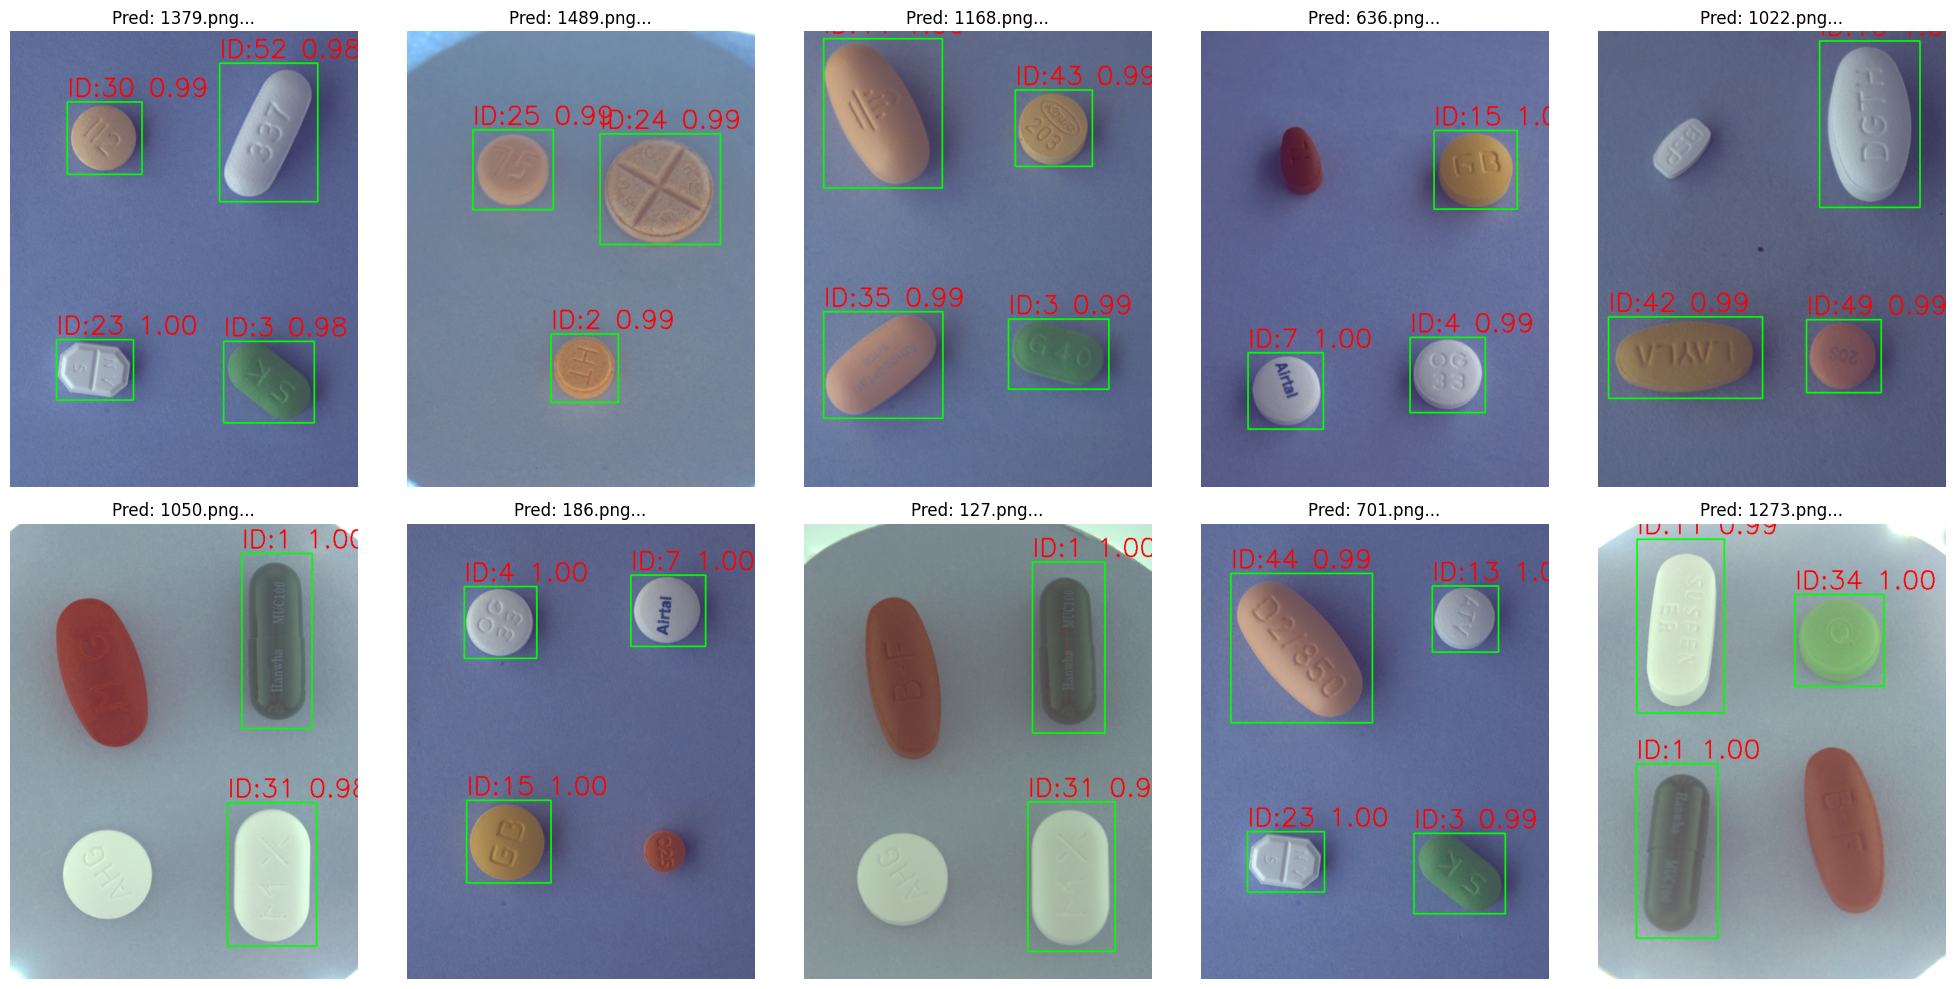

In [ ]:
import matplotlib.pyplot as plt
import random

def load_model(checkpoint_path, num_classes, device):
    model = fasterrcnn_resnet50_fpn(pretrained=False)
    
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)

    model.to(device)
    model.eval()
    return model

#임시로 모델의 입력값과 일치시키기 위한 함수
def get_test_transform():
    return A.Compose([
        A.LongestMaxSize(max_size=800),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
num_classes = 57
model = load_model(r"C:\Users\thsdu\pill_model_CLAHE_ep15.pth", num_classes, device)

def run_inference_on_folder(model, folder_path, device, num_samples=10):
    valid_exts = ('.png', '.jpg', '.jpeg', '.JPG', '.PNG')
    img_files = [f for f in os.listdir(folder_path) if f.endswith(valid_exts)]
    
    if len(img_files) < num_samples:
        num_samples = len(img_files)
    
    selected_files = random.sample(img_files, num_samples)
    transform = get_test_transform()
    
    plt.figure(figsize=(20, 10))

    for i, file_name in enumerate(selected_files):
        img_path = os.path.join(folder_path, file_name)
        
        img_array = np.fromfile(img_path, np.uint8)
        img_bgr = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        transformed = transform(image=img_rgb)
        input_tensor = transformed["image"].to(device).unsqueeze(0)
        
        vis_resizer = A.Compose([A.LongestMaxSize(max_size=800)])
        vis_img = vis_resizer(image=img_rgb)["image"]

        with torch.no_grad():
            outputs = model(input_tensor)

        boxes = outputs[0]['boxes'].cpu().numpy()
        scores = outputs[0]['scores'].cpu().numpy()
        labels = outputs[0]['labels'].cpu().numpy()


        for box, score, label in zip(boxes, scores, labels):
            if score > 0.5: # 신뢰도 임계값
                x1, y1, x2, y2 = box.astype(int)
                cv2.rectangle(vis_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                text = f"ID:{label} {score:.2f}"
                cv2.putText(vis_img, text, (x1, y1 - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 0, 0), 2)

        plt.subplot(2, 5, i + 1)
        plt.imshow(vis_img)
        plt.title(f"Pred: {file_name[:10]}...")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

run_inference_on_folder(model, r'C:\Users\thsdu\Desktop\beg_project\sprint_ai_project1_data\test_images', device)


In [ ]:
import os
import json
import cv2
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO

# ------------------------------
# IoU 계산
# ------------------------------
def compute_iou(box1, box2):
    """
    box format: [x1, y1, x2, y2]
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union = area1 + area2 - inter
    return inter / union if union != 0 else 0


# ------------------------------
# AP 계산
# ------------------------------
def compute_ap(recalls, precisions):
    recalls = np.concatenate(([0], recalls, [1]))
    precisions = np.concatenate(([0], precisions, [0]))

    for i in range(len(precisions)-1, 0, -1):
        precisions[i-1] = max(precisions[i-1], precisions[i])

    idx = np.where(recalls[1:] != recalls[:-1])[0]
    ap = np.sum((recalls[idx+1] - recalls[idx]) * precisions[idx+1])
    return ap


# ------------------------------
# AP @ IoU threshold
# ------------------------------
def ap_at_iou(pred_boxes, pred_scores, gt_boxes, iou_threshold):

    sorted_idx = np.argsort(-pred_scores)
    pred_boxes = pred_boxes[sorted_idx]
    pred_scores = pred_scores[sorted_idx]

    tp = np.zeros(len(pred_boxes))
    fp = np.zeros(len(pred_boxes))
    matched = set()

    for i, pbox in enumerate(pred_boxes):
        best_iou = 0
        best_gt = -1

        for j, gt in enumerate(gt_boxes):
            iou = compute_iou(pbox, gt)
            if iou > best_iou:
                best_iou = iou
                best_gt = j

        if best_iou >= iou_threshold and best_gt not in matched:
            tp[i] = 1
            matched.add(best_gt)
        else:
            fp[i] = 1

    tp = np.cumsum(tp)
    fp = np.cumsum(fp)

    recalls = tp / len(gt_boxes) if len(gt_boxes) > 0 else np.array([0.0])
    precisions = tp / (tp + fp + 1e-6)

    return compute_ap(recalls, precisions)


# ------------------------------
# mAP75-95 계산
# ------------------------------
def map75_95(pred_boxes, pred_scores, gt_boxes):
    if len(gt_boxes) == 0:
        return 0.0, []
    iou_thresholds = np.arange(0.75, 1.00, 0.05)
    aps = []
    for t in iou_thresholds:
        ap = ap_at_iou(pred_boxes, pred_scores, gt_boxes, t)
        aps.append(ap)
    return np.mean(aps), aps



In [ ]:
class TriplePillEnsemble:
    def __init__(self, model_paths, device):
        self.models = []
        self.mappings = []
        self.device = device
        
        for path in model_paths:
            # 학습 코드에서 저장한 가중치와 매핑 정보를 로드
            checkpoint = torch.load(path, map_location=device)
            mapping = checkpoint['label_mapping']
            shape_type = checkpoint.get('shape_type', 'unknown')
            
            # 모델 구조 재건 (배경 포함 클래스 수)
            num_classes = len(mapping) + 1
            model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None, num_classes=num_classes)
            model.load_state_dict(checkpoint['model_state_dict'])
            model.to(device)
            model.eval()
            
            self.models.append(model)
            self.mappings.append(mapping)
            print(f"📦 Loaded {shape_type} model from {os.path.basename(path)} (Classes: {len(mapping)})")

    def __call__(self, img_tensor):
        all_boxes = []
        all_scores = []
        all_labels = []

        for i, model in enumerate(self.models):
            with torch.no_grad():
                prediction = model(img_tensor)[0]
                
                # [중요] 학습 시 사용된 label_mapping (이름 -> 번호)을 
                # 평가용 공통 ID로 변환하는 로직 (이름을 기준으로 매칭)
                inv_map = {v: k for k, v in self.mappings[i].items()} # 번호 -> 이름
                
                boxes = prediction['boxes']
                scores = prediction['scores']
                labels = prediction['labels'].cpu().numpy()

                for idx, lbl in enumerate(labels):
                    # 배경(0)이 아닌 경우만 처리
                    if lbl == 0: continue
                    
                    # 현재 모델에서의 클래스 이름 추출
                    pill_name = inv_map.get(lbl)
                    
                    # 여기에 공통 ID 부여 로직 (필요시 수정)
                    # 만약 이름 자체가 고유하다면 해시나 사전 정의된 ID를 사용
                    common_id = hash(pill_name) % 10000 
                    
                    all_boxes.append(boxes[idx].unsqueeze(0))
                    all_scores.append(scores[idx].unsqueeze(0))
                    all_labels.append(torch.tensor([common_id]).to(self.device))

        if not all_boxes:
            return [{'boxes': torch.empty((0, 4)), 'scores': torch.tensor([]), 'labels': torch.tensor([])}]

        combined_boxes = torch.cat(all_boxes, dim=0)
        combined_scores = torch.cat(all_scores, dim=0)
        combined_labels = torch.cat(all_labels, dim=0)

        keep = torchvision.ops.batched_nms(combined_boxes, combined_scores, combined_labels, iou_threshold=0.5)

        return [{
            'boxes': combined_boxes[keep],
            'scores': combined_scores[keep],
            'labels': combined_labels[keep]
        }]

In [ ]:
def evaluate_ensemble_map(model_paths, img_dir, gt_json_dir, device):
    ensemble_model = TriplePillEnsemble(model_paths, device)
    
    img_files = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))]
    aps = []

    for fname in img_files[:20]: # 샘플 20장 진행
        img_path = os.path.join(img_dir, fname)
        img_bgr = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_tensor = F.to_tensor(img_rgb).unsqueeze(0).to(device)

        # 앙상블 추론
        pred = ensemble_model(img_tensor)[0]
        
        # GT 로드
        json_path = os.path.join(gt_json_dir, os.path.splitext(fname)[0] + '.json')
        gt_boxes = []
        if os.path.exists(json_path):
            with open(json_path, 'r', encoding='utf-8') as f:
                gt_data = json.load(f)
            for ann in gt_data.get('annotations', []):
                x, y, w, h = ann['bbox']
                gt_boxes.append([x, y, x + w, y + h])
        
        gt_boxes = np.array(gt_boxes)
        
        # mAP@75-95 계산
        mAP, _ = map75_95(pred['boxes'].cpu().numpy(), pred['scores'].cpu().numpy(), gt_boxes)
        aps.append(mAP)
        print(f"{fname} -> mAP: {mAP:.4f}")

    print(f"\n최종 평균 mAP@.75-.95: {np.mean(aps):.4f}")

# ---------------------------------------------------------
# 3. 메인 실행
# ---------------------------------------------------------
MODEL_PATHS = [
    'pill_model_Model_circle_final.pth',
    'pill_model_Model_rectangle_final.pth',
    'pill_model_Model_oval_final.pth'
]
VAL_IMG_DIR = r'C:\...\fixed_data\all_images'
VAL_JSON_DIR = r'C:\...\fixed_data\all_annotations'

evaluate_ensemble_map(MODEL_PATHS, VAL_IMG_DIR, VAL_JSON_DIR, 'cuda')